# San Francisco Airport - Clustering Project

## Proje Hakkında

Bu proje, San Francisco Havalimanı'ndaki yolcu trafiği istatistiklerini kullanarak havayolu şirketlerini benzerliklerine göre gruplandırmayı (clustering) amaçlamaktadır. Veri seti, havayolu şirketlerinin aylık yolcu sayılarını, uçuş tiplerini (İç Hat/Dış Hat) ve terminal bilgilerini içermektedir. Bu projede K-Means algoritması kullanılarak havayolları, taşıdıkları yolcu hacmi ve operasyon türlerine göre segmentlere ayrılacaktır.

**Kullanılan Yöntemler:**
* Veri Keşfi ve Analizi (EDA)
* Özellik Mühendisliği (Feature Engineering)
* Elbow Metodu ile Optimum Küme Sayısının Belirlenmesi (Yellowbrick)
* K-Means Kümeleme

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv('air-traffic-passenger-statistics.csv')

### EDA (Veri Keşfi ve Analizi)

In [7]:
df.head()

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090


In [8]:
df.isnull().sum()

Activity Period                 0
Operating Airline               0
Operating Airline IATA Code    63
Published Airline               0
Published Airline IATA Code    63
GEO Summary                     0
GEO Region                      0
Activity Type Code              0
Price Category Code             0
Terminal                        0
Boarding Area                   0
Passenger Count                 0
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18885 entries, 0 to 18884
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Activity Period              18885 non-null  int64 
 1   Operating Airline            18885 non-null  object
 2   Operating Airline IATA Code  18822 non-null  object
 3   Published Airline            18885 non-null  object
 4   Published Airline IATA Code  18822 non-null  object
 5   GEO Summary                  18885 non-null  object
 6   GEO Region                   18885 non-null  object
 7   Activity Type Code           18885 non-null  object
 8   Price Category Code          18885 non-null  object
 9   Terminal                     18885 non-null  object
 10  Boarding Area                18885 non-null  object
 11  Passenger Count              18885 non-null  int64 
dtypes: int64(2), object(10)
memory usage: 1.7+ MB


In [10]:
# En çok yolcu taşıyan ilk 10 havayolu
top_airlines = df.groupby('Operating Airline')['Passenger Count'].sum().sort_values(ascending=False).head(10)

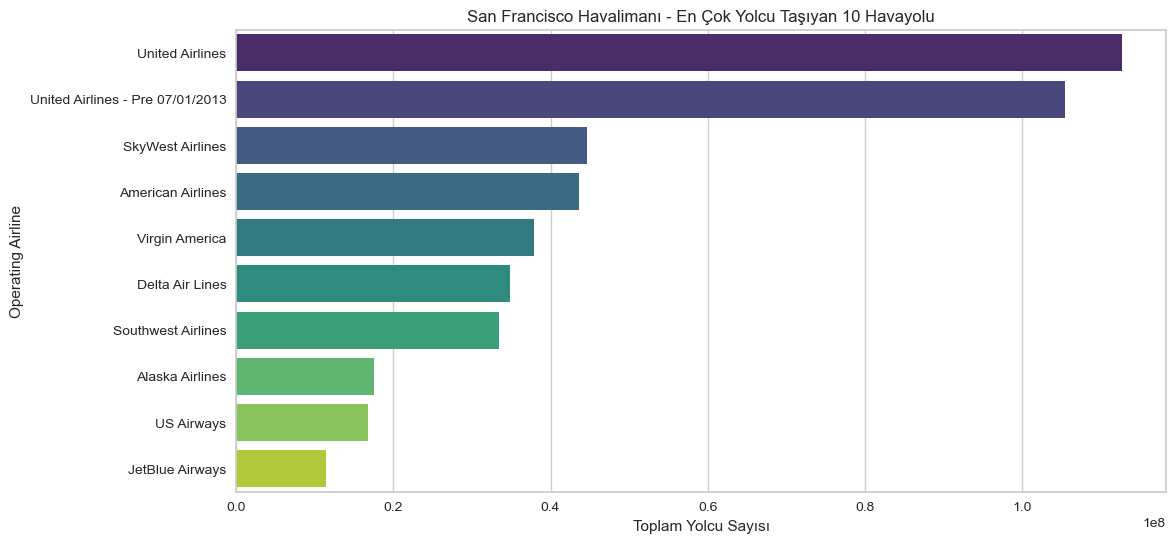

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_airlines.values, y=top_airlines.index, palette='viridis')
plt.title('San Francisco Havalimanı - En Çok Yolcu Taşıyan 10 Havayolu')
plt.xlabel('Toplam Yolcu Sayısı')
plt.show()

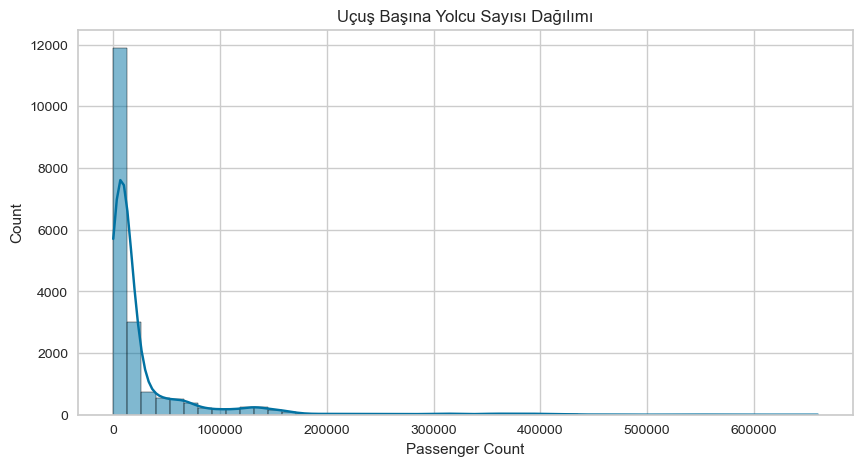

In [12]:
# Yolcu Sayısı Dağılımı (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['Passenger Count'], bins=50, kde=True)
plt.title('Uçuş Başına Yolcu Sayısı Dağılımı')
plt.show()

### Feature Engineering

In [14]:
# Havayolu ve Uçuş Tipi (GEO Summary) bazında toplam yolcu sayıları
airline_stats = df.pivot_table(
    index='Operating Airline', 
    columns='GEO Summary', 
    values='Passenger Count', 
    aggfunc='sum'
).fillna(0) # NaN değerleri 0 yapıyoruz (Örn: Sadece iç hat uçanların dış hat değeri 0 olsun)

In [16]:
# Sütun isimlerini düzenleme
airline_stats.columns = ['Domestic', 'International']
airline_stats.name = None  # Index ismini temizle

In [17]:
airline_stats.head()

,Domestic,International
Operating Airline,,
ABC Aerolineas S.A. de C.V. dba Interjet,0.0,15585.0
ATA Airlines,383773.0,991.0
Aer Lingus,0.0,777691.0
Aeromexico,0.0,1672946.0
Air Berlin,0.0,235155.0


In [18]:
# Kümeleme için veriyi hazırlama
X = airline_stats[['Domestic', 'International']]

In [19]:
# Scaling (Standartlaştırma)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X

,Domestic,International
Operating Airline,,
ABC Aerolineas S.A. de C.V. dba Interjet,0.0,15585.0
ATA Airlines,383773.0,991.0
Aer Lingus,0.0,777691.0
Aeromexico,0.0,1672946.0
Air Berlin,0.0,235155.0
...,...,...
WOW Air,0.0,295168.0
WestJet Airlines,0.0,799801.0
World Airways,271.0,514.0


### Elbow Metodu ile Optimum Küme Sayısı
Yellowbrick kütüphanesini kullanarak optimum küme sayısını belirleyelim.

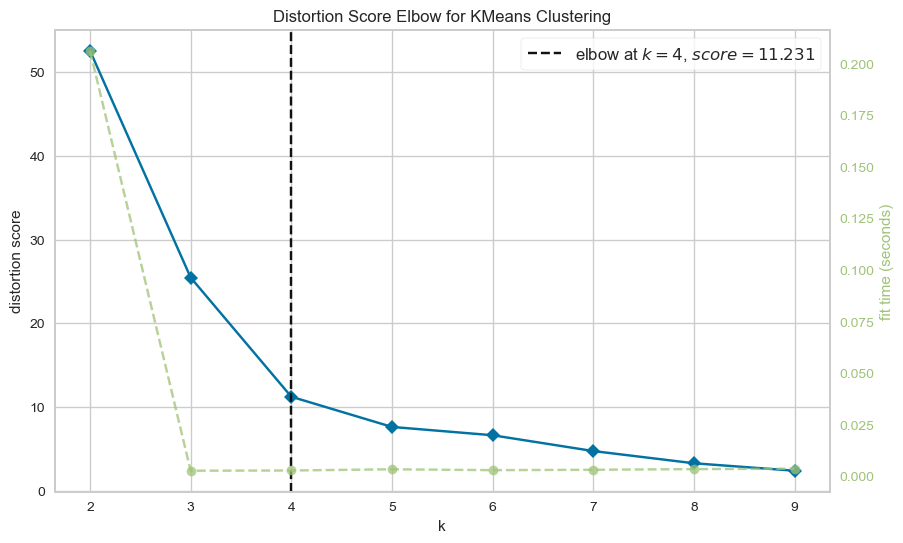

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [23]:
# K-Means ve Elbow Görselleştirici
model = KMeans(random_state=42)
visualizer = KElbowVisualizer(model, k=(2,10))
plt.figure(figsize=(10,6))
visualizer.fit(X_scaled)        # Veriyi fit et
visualizer.show()               # Grafiği göster

Bu grafik sonucunda genellikle k=3 veya k=4 en uygun nokta olarak görünür. Biz analize 4 küme ile devam edeceğiz

### K-Means Kümeleme ve Görselleştirme

In [25]:
# Modelin 4 küme ile kurulması
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [26]:
# Kümeleri veriye ekleme
airline_stats['Cluster'] = clusters

In [27]:
# Küme Merkezlerini (Centroids) gerçek değerlere geri döndürme
centers = scaler.inverse_transform(kmeans.cluster_centers_)

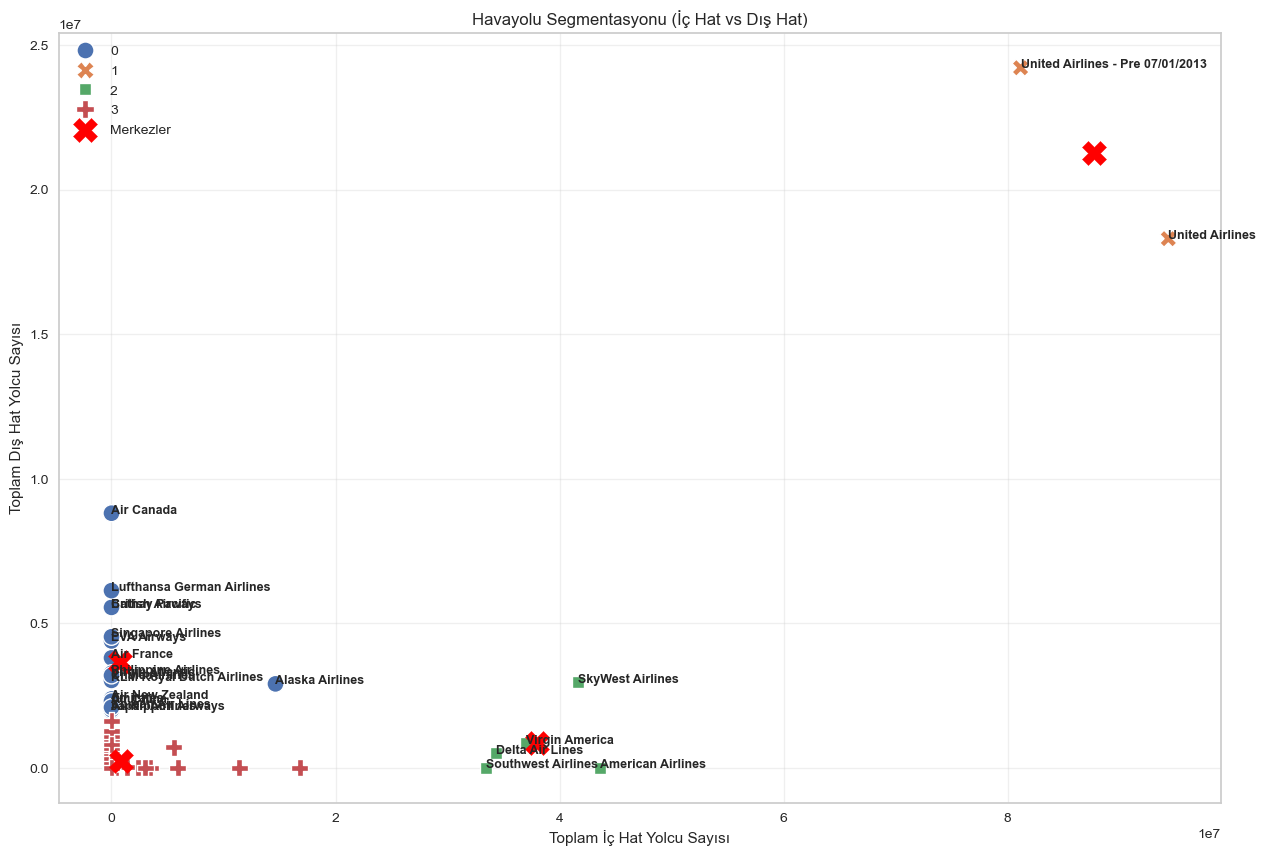

In [28]:
# Sonuçları Görselleştirme
plt.figure(figsize=(15, 10))
sns.scatterplot(
    x='Domestic', 
    y='International', 
    hue='Cluster', 
    data=airline_stats, 
    palette='deep', 
    s=150, 
    style='Cluster'
)

# Merkezleri çizdirme
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=300, marker='X', label='Merkezler')

# Bazı önemli havayollarının isimlerini grafiğe yazdırma (Okunabilirlik için)
for i in range(airline_stats.shape[0]):
    # Sadece büyük havayollarını etiketleyelim (kalabalık olmaması için)
    if airline_stats.iloc[i]['Domestic'] > 2e7 or airline_stats.iloc[i]['International'] > 2e6:
        plt.text(
            airline_stats.iloc[i]['Domestic'], 
            airline_stats.iloc[i]['International'], 
            airline_stats.index[i],
            fontsize=9, 
            weight='bold'
        )

plt.title('Havayolu Segmentasyonu (İç Hat vs Dış Hat)')
plt.xlabel('Toplam İç Hat Yolcu Sayısı')
plt.ylabel('Toplam Dış Hat Yolcu Sayısı')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Proje Sonucu

Öneri: Havalimanı yönetimi, "Dominant Taşıyıcılar" için özel terminal alanları tahsis ederken, "Dış Hat Odaklılar" için uluslararası terminal kapasitesini optimize etmelidir.